<a href="https://colab.research.google.com/github/svetlanama/ai_practice/blob/dev/DZ_21.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Завдання

* Завантажте дані
* Розділіть дані на тренувальні та тестові
* У `MyTokenizer` добавте обробку тексту за допомогою `nltk`, застосуйте **стематизацію**
* Застосуйте `TfidfVectorizer`
* Застосуйте `TruncatedSVD`
* Натренуйте модель [SVC](https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html#sklearn.svm.SVC) з параметром `kernel="linear"`, якщо вистачить пам'яті можна спробувати `kernel="rbf"`
* Виведіть результати

# Дані про телеграм

In [3]:
import pandas as pd

df = pd.read_csv("https://raw.githubusercontent.com/HalyshAnton/IT-Step-Pyton-AI/main/module6/data/telegram_spam.csv")

In [19]:
from sklearn.model_selection import train_test_split



X = df['text']
y = df['text_type']

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, stratify=y)

In [20]:
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from sklearn.feature_extraction.text import TfidfVectorizer



nltk.download('punkt_tab')
nltk.download('stopwords')


class MyTokenizer:
    def __init__(self):
        self.stemmer = PorterStemmer()
        self.stop_words = set(stopwords.words('english'))

    def __call__(self, text):
        tokens = word_tokenize(text.lower())
        filtered_tokens = [token for token in tokens if token not in self.stop_words]
        stemmed = [self.stemmer.stem(token) for token in filtered_tokens]
        return stemmed

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [21]:
tokenizer = MyTokenizer()
tfidf = TfidfVectorizer(tokenizer=tokenizer, max_features=3_000)
X_train = tfidf.fit_transform(X_train)
X_test = tfidf.transform(X_test)

/usr/local/lib/python3.10/dist-packages/sklearn/feature_extraction/text.py:521: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


In [22]:
from sklearn.decomposition import TruncatedSVD

pca = TruncatedSVD(1745+1)
X_train_transformed = pca.fit_transform(X_train)
X_test_transformed = pca.transform(X_test)

In [24]:
pca.explained_variance_ratio_.sum()

0.9180643991570054

In [25]:
pca.explained_variance_ratio_.cumsum()

array([0.02446829, 0.03712214, 0.04519585, ..., 0.91782905, 0.91794692,
       0.9180644 ])

In [26]:
import numpy as np

np.where(pca.explained_variance_ratio_.cumsum() >= 0.87)

(array([1422, 1423, 1424, 1425, 1426, 1427, 1428, 1429, 1430, 1431, 1432,
        1433, 1434, 1435, 1436, 1437, 1438, 1439, 1440, 1441, 1442, 1443,
        1444, 1445, 1446, 1447, 1448, 1449, 1450, 1451, 1452, 1453, 1454,
        1455, 1456, 1457, 1458, 1459, 1460, 1461, 1462, 1463, 1464, 1465,
        1466, 1467, 1468, 1469, 1470, 1471, 1472, 1473, 1474, 1475, 1476,
        1477, 1478, 1479, 1480, 1481, 1482, 1483, 1484, 1485, 1486, 1487,
        1488, 1489, 1490, 1491, 1492, 1493, 1494, 1495, 1496, 1497, 1498,
        1499, 1500, 1501, 1502, 1503, 1504, 1505, 1506, 1507, 1508, 1509,
        1510, 1511, 1512, 1513, 1514, 1515, 1516, 1517, 1518, 1519, 1520,
        1521, 1522, 1523, 1524, 1525, 1526, 1527, 1528, 1529, 1530, 1531,
        1532, 1533, 1534, 1535, 1536, 1537, 1538, 1539, 1540, 1541, 1542,
        1543, 1544, 1545, 1546, 1547, 1548, 1549, 1550, 1551, 1552, 1553,
        1554, 1555, 1556, 1557, 1558, 1559, 1560, 1561, 1562, 1563, 1564,
        1565, 1566, 1567, 1568, 1569, 

In [27]:
from sklearn.svm import SVC

model = SVC(kernel="linear")

model.fit(X_train, y_train)
model

SVC(kernel='linear')

In [28]:
y_pred = model.predict(X_test)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         ham       0.94      0.96      0.95      2868
        spam       0.91      0.86      0.89      1202

    accuracy                           0.93      4070
   macro avg       0.93      0.91      0.92      4070
weighted avg       0.93      0.93      0.93      4070



[]

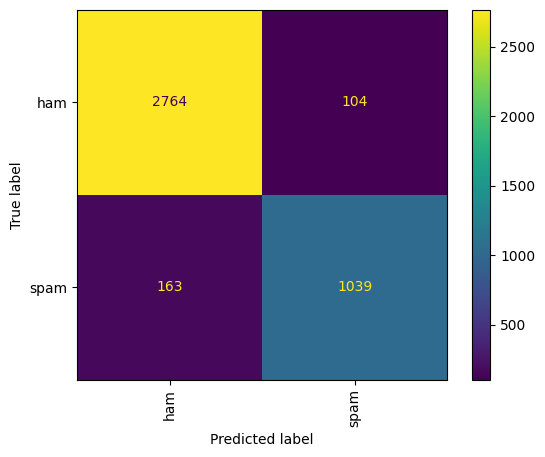

In [29]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt


ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.xticks(rotation=90)
plt.plot()